In [1]:
import os
import sys
if '../' not in sys.path:
    sys.path.append('../')

from functools import partial
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from mcp_boltzmann import annihilation as ann

In [2]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

In [3]:
MeV = 1
GeV = 1e3*MeV

m_mcp = 100.0*MeV

m_e = 0.511*MeV
m_mu = 105*MeV
m_tau = 1776*MeV
m_s = 95*MeV
m_c = 1270*MeV
m_b = 4180*MeV
m_t = 172.76*GeV
m_pi = 139.570 * MeV
Q = 1e-9 #mcp charge

In [4]:
m_t

172760.0

In [5]:
sigma_ee_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_l = m_e)
sigma_mumu_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_l = m_mu)
sigma_tautau_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_l = m_tau)

sigma_lq_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_l = 0.0)
sigma_ss_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_l = m_s)
sigma_cc_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_l = m_c)
sigma_bb_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_l = m_b)
sigma_tt_ff = partial(ann.sigma_llff, m_mcp = m_mcp, m_l = m_t)

sigma_pipi_ff = partial(ann.sigma_pipiff, m_mcp = m_mcp)

In [6]:
# T_int = np.geomspace(1e-3, 1e6, 10000)
T_int = np.geomspace(1e-3, 1e6, 200)

Ix_table_e = np.array(
    [ann.Ix_fermi(sigma_ee_ff, m_mcp, m_e, T) for T in T_int]
)

Ix_table_e_MB = np.array(
    [ann.Ix(sigma_ee_ff, m_mcp, m_e, T) for T in T_int]
)

Ix_table_mu = np.array(
    [ann.Ix_fermi(sigma_mumu_ff, m_mcp, m_mu, T) for T in T_int]
)

Ix_table_tau = np.array(
    [ann.Ix_fermi(sigma_tautau_ff, m_mcp, m_tau, T) for T in T_int]
)

Ix_table_lq = np.array(
    [ann.Ix_fermi(sigma_lq_ff, m_mcp, 0.0, T) for T in T_int]
)

Ix_table_strange = np.array(
    [ann.Ix_fermi(sigma_ss_ff, m_mcp, m_s, T) for T in T_int]
)

Ix_table_charm = np.array(
    [ann.Ix_fermi(sigma_cc_ff, m_mcp, m_c, T) for T in T_int]
)

Ix_table_bot = np.array(
    [ann.Ix_fermi(sigma_bb_ff, m_mcp, m_b, T) for T in T_int]
)

Ix_table_top = np.array(
    [ann.Ix_fermi(sigma_tt_ff, m_mcp, m_t, T) for T in T_int]
)

/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/annihilation.py:166: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = quad(
/Users/duncan/src/mcp_boltzmann/notebooks/../mcp_boltzmann/annihilation.py:146: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = quad(


In [7]:
Ix_table_pipi = np.array(
    [ann.Ix(sigma_pipi_ff, m_mcp, m_pi, T) for T in T_int]
)

/var/folders/9z/c613c55s37gc7sthc_2397hc0000gn/T/ipykernel_45310/481797948.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(T_int, Ix_table_e/Ix_table_e_MB)


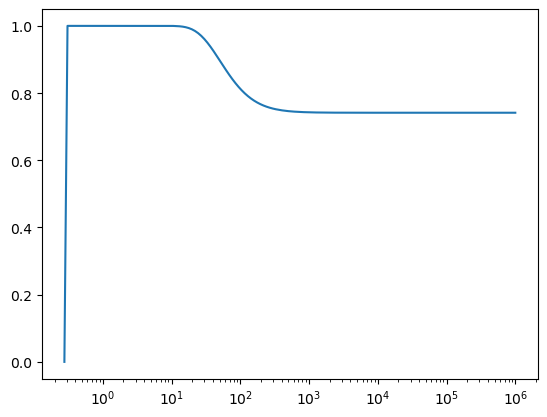

In [8]:
plt.plot(T_int, Ix_table_e/Ix_table_e_MB)
plt.xscale('log')

In [9]:
# np.savez_compressed('../output/rates/ann_ee_ff_m_10.npz', 
#                     Temp_grid=T_int,
#                     rate=Ix_table_e
#                    )

# np.savez_compressed('../output/rates/ann_mumu_ff_m_10.npz', 
#                     Temp_grid=T_int,
#                     rate=Ix_table_mu
#                    )
LQCD = 200*MeV
rate_EM = Ix_table_e + Ix_table_mu + Ix_table_tau
rate_qcd = np.heaviside(T_int - LQCD, 0)*(Ix_table_lq + Ix_table_strange + Ix_table_charm + Ix_table_bot + Ix_table_top)
rate_had = np.heaviside(LQCD - T_int, 0)*Ix_table_pipi
rate_tot = rate_EM + rate_qcd

np.savez_compressed(f'../output/rates/annihilation/ann_m_{m_mcp}_Q_1.npz',
                   Temp_grid=T_int,
                   rate=rate_tot
                   )

In [10]:
_Ix_table_e_I = interp1d(T_int, Ix_table_e, bounds_error=False, fill_value=(0, Ix_table_e[-1]))
_Ix_table_mu_I = interp1d(T_int, Ix_table_mu, bounds_error=False, fill_value=(0, Ix_table_mu[-1]))
_Ix_table_tau_I = interp1d(T_int, Ix_table_tau, bounds_error=False, fill_value=(0, Ix_table_tau[-1]))

_Ix_table_lq_I = interp1d(T_int, Ix_table_lq, bounds_error=False, fill_value=(0, Ix_table_lq[-1]))
_Ix_table_s_I = interp1d(T_int, Ix_table_strange, bounds_error=False, fill_value=(0, Ix_table_strange[-1]))
_Ix_table_c_I = interp1d(T_int, Ix_table_charm, bounds_error=False, fill_value=(0, Ix_table_charm[-1]))
_Ix_table_b_I = interp1d(T_int, Ix_table_bot, bounds_error=False, fill_value=(0, Ix_table_bot[-1]))
_Ix_table_t_I = interp1d(T_int, Ix_table_top, bounds_error=False, fill_value=(0, Ix_table_top[-1]))

_Ix_table_pi_I = interp1d(T_int, Ix_table_pipi, bounds_error=False, fill_value=(0, Ix_table_pipi[-1]))

In [11]:
def C_f_ee(T, Q):
    return Q**2*_Ix_table_e_I(T)

def C_f_mumu(T, Q):
    return Q**2*_Ix_table_mu_I(T)

def C_f_tautau(T, Q):
    return Q**2*_Ix_table_tau_I(T)

def C_f_lq(T, Q):
    q_u = 2/3
    q_d = -1/3
    N_c = 3

    return N_c*Q**2*(q_u**2 + q_d**2)*_Ix_table_lq_I(T)

def C_f_ss(T, Q):
    q_s = -1/3
    N_c = 3

    return N_c*Q**2*(q_s**2)*_Ix_table_s_I(T) 

def C_f_cc(T, Q):
    q_c = 2/3
    N_c = 3

    return N_c*Q**2*(q_c**2)*_Ix_table_c_I(T) 

def C_f_bb(T, Q):
    q_b = -1/3
    N_c = 3

    return N_c*Q**2*(q_b**2)*_Ix_table_b_I(T) 

def C_f_tt(T, Q):
    q_t = 2/3
    N_c = 3

    return N_c*Q**2*(q_t**2)*_Ix_table_t_I(T) 

def C_f_pipi(T, Q):
    return Q**2*_Ix_table_pi_I(T)

In [12]:
T_plot = np.geomspace(1e-3, 1e6, 1000)

In [13]:
shelton_f_ann = load_csv('../input/fig/2206.13530_fig7_left_annihilation.csv')
shelton_f_ann_fig8 = load_csv('../input/fig/2206.13530_fig8_left_annihilation.csv')

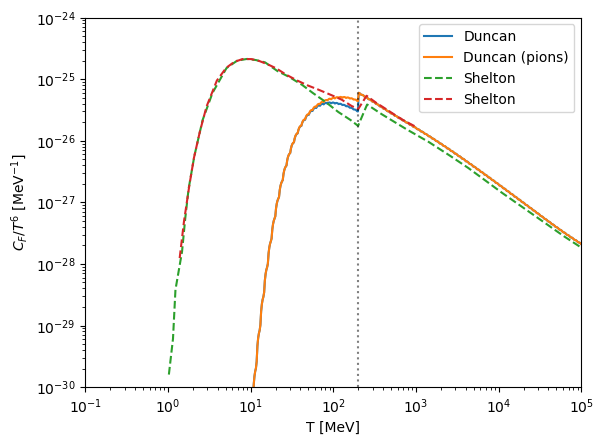

In [14]:
LQCD = 200*MeV
T_EW = 160*GeV

res_e = C_f_ee(T_plot, 1e-9)/T_plot**6
res_mu = C_f_mumu(T_plot, 1e-9)/T_plot**6
res_tau =  C_f_tautau(T_plot, 1e-9)/T_plot**6

res_lq = C_f_lq(T_plot, 1e-9)/T_plot**6
res_s = C_f_ss(T_plot, 1e-9)/T_plot**6
res_c = C_f_cc(T_plot, 1e-9)/T_plot**6
res_b = C_f_bb(T_plot, 1e-9)/T_plot**6
res_t = C_f_tt(T_plot, 1e-9)/T_plot**6

res_pi = np.heaviside(LQCD - T_plot , 0)*C_f_pipi(T_plot, 1e-9)/T_plot**6

res_em = res_e + res_mu
# res_em = res_e + res_mu + res_tau
res_qcd = (res_lq + res_s + res_c + res_b + res_t)*np.heaviside(T_plot - LQCD, 0)

# plt.plot(T_plot, 0.25*T_plot*res_e)
# plt.plot(T_plot, 0.25*T_plot*(res_em + res_qcd))
# plt.plot(T_plot, 0.25*T_plot*(res_mu))
# plt.plot(T_plot, (res_e+res_mu))
plt.plot(T_plot, (res_em + res_qcd), label='Duncan')
plt.plot(T_plot, (res_em + res_qcd) + res_pi, label='Duncan (pions)')

# plt.plot(T_plot, (res_e + res_qcd))
# plt.plot(T_plot, 0.25*T_plot*(res_mu))
# plt.plot(T_plot, 0.25*T_plot*(res_tau))

plt.plot(np.array(shelton_f_ann[0])*1e3, shelton_f_ann[1], label='Shelton', linestyle='dashed')
plt.plot(np.array(shelton_f_ann_fig8[0]), shelton_f_ann_fig8[1], label='Shelton', linestyle='dashed')
plt.yscale('log')
plt.xscale('log')

plt.xlabel('T [MeV]')
plt.ylabel(r'$C_{F}/T^6$ [MeV$^{-1}$]')

plt.axvline(LQCD, linestyle='dotted', color='black', alpha=0.5)
plt.axvline(T_EW, linestyle='dotted', color='black', alpha=0.5)


plt.ylim(1e-30, 1e-24)
plt.xlim(1e-1, 1e5)

plt.legend()

plt.show()

In [15]:
C_f_pipi(100, 1e-9)

8.150519055854301e-15

In [16]:
np.heaviside(LQCD - T_int, 0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [17]:
Ix_table_pipi

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0